# Reducing Corporate Churn: An Actionable Data Audit Using Python and Correlation Analysis

**Analyst:** Reliance Adegunloye
**Dataset:** IBM HR Analytics Employee Attrition & Performance — 1,470 employees, 35 attributes
**Tools:** Python (pandas, numpy, matplotlib, seaborn)

## 1. Business Context

Every employee who leaves takes institutional knowledge with them and costs the company time and money to replace. Before recommending a fix, HR needs to know **which factors actually drive people to quit** — not guess.

**Guiding questions for this audit:**
- How many employees are leaving, and is that rate actually a concern?
- Which employee characteristics show up most often among those who leave?
- Do pay, commute distance, age, or tenure meaningfully relate to attrition?
- Which departments and roles are most exposed?
- Does working overtime make someone more likely to quit?
- Of everything measured, what correlates *most strongly* with attrition — and what doesn't?

The notebook below answers these in order: broad patterns first (Exploratory Data Analysis), statistical ranking second (Correlation Analysis), and business recommendations last.

## Executive Summary

**The problem:** 16.1% of the workforce (237 of 1,470 employees) left the company.

**The method:** Exploratory data analysis across 35 employee attributes, followed by a full correlation analysis — numeric fields and one-hot-encoded categorical fields — to rank what actually predicts attrition.

**Top findings:**
1. **Overtime is the strongest single driver.** Employees who work overtime leave at roughly 2.9x the rate of those who don't (30.5% vs. 10.4%).
2. **Pay matters.** Employees who left earned noticeably less, on average, than those who stayed.
3. **Commute distance is the leading numeric correlate** with attrition — ahead of every other measured numeric factor, though the effect size is modest.
4. **Risk concentrates** among single employees, frequent travelers, and Sales Representatives.
5. **Tenure and seniority protect against attrition** — long-serving, senior employees are the least likely to leave.

**Top recommendations:** rein in overtime reliance, close the pay gap for at-risk groups, and offer flexible or hybrid arrangements for long-commute employees. Full evidence and reasoning below.

---

## 2. Data Overview & Quality Audit

Before drawing any conclusions, I check what I'm working with: how many records, what the fields represent, and whether missing or inconsistent data needs cleaning first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
ibm_data = pd.read_csv('HR-Employee-Attrition.csv')
ibm_data.head().T

,0,1,2,3,4
Age,41,49,37,33,27
Attrition,Yes,No,Yes,No,No
BusinessTravel,Travel_Rarely,Travel_Frequently,Travel_Rarely,Travel_Frequently,Travel_Rarely
DailyRate,1102,279,1373,1392,591
Department,Sales,Research & Development,Research & Development,Research & Development,Research & Development
DistanceFromHome,1,8,2,3,2
Education,2,1,2,4,1
EducationField,Life Sciences,Life Sciences,Other,Life Sciences,Medical
EmployeeCount,1,1,1,1,1
EmployeeNumber,1,2,4,5,7


In [3]:
ibm_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
ibm_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


Daily rate, monthly income, and monthly rate carry high standard deviations relative to their means — a sign of meaningful spread across pay grades rather than measurement noise. Nothing beyond expected business variation stands out as an outlier.

In [5]:
missing_values = ibm_data.isna().sum()
print(f"Total missing values across all 35 columns: {missing_values.sum()}")

Total missing values across all 35 columns: 0


No missing values anywhere in the dataset — it's clean and ready for analysis without imputation.

One more prep step before the EDA: I convert the target variable, `Attrition`, into a numeric flag (`Attrition_num`) up front, since both the EDA and the correlation analysis need a numeric target to work with.

In [6]:
ibm_data['Attrition_num'] = ibm_data['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

## 3. Exploratory Data Analysis

With the data confirmed clean, I look for patterns — starting broad (how many people are leaving) and narrowing toward specific factors (pay, distance, age, department, overtime).

### 3.1 How Many Employees Are We Losing?

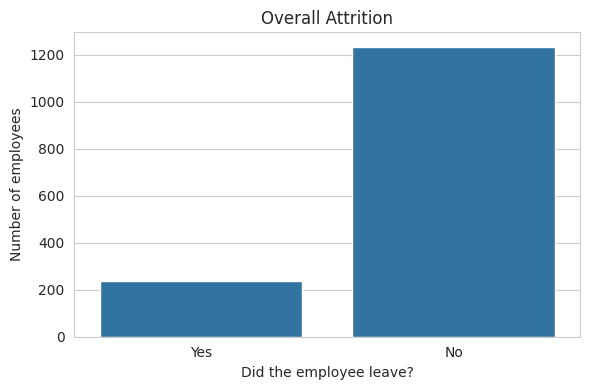

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=ibm_data)
plt.title('Overall Attrition')
plt.xlabel('Did the employee leave?')
plt.ylabel('Number of employees')
plt.tight_layout()
plt.savefig('attrition_count_plot.jpg', dpi=150)
plt.show()

In [8]:
leavers_count = len(ibm_data[ibm_data['Attrition'] == 'Yes'])
attrition_rate = leavers_count / len(ibm_data) * 100
print(f"{leavers_count} employees left the company out of {len(ibm_data)} — an attrition rate of {attrition_rate:.1f}%.")

237 employees left the company out of 1470 — an attrition rate of 16.1%.


**Takeaway:** At 16.1%, roughly 1 in 6 employees left. That's high enough to justify digging into *why*.

### 3.2 Who Is Most Likely to Leave?

To spot patterns quickly, I one-hot encode the key categorical fields and count how often each trait appears among employees who actually left.

In [9]:
sub_data = ibm_data[['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
                     'JobRole', 'MaritalStatus', 'OverTime']]
ibm_cat_data = pd.DataFrame(sub_data)

ibm_cat_data['Attrition_num'] = ibm_cat_data['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
ibm_cat_data = ibm_cat_data.drop(columns=['Attrition'])
ibm_cat_data = pd.get_dummies(ibm_cat_data)
ibm_cat_data.head(3)

,Attrition_num,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,...,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,1,False,False,True,False,False,True,False,True,False,...,False,False,False,True,False,False,False,True,False,True
1,0,False,True,False,False,True,False,False,True,False,...,False,False,True,False,False,False,True,False,True,False
2,1,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True


In [10]:
# Distribution of attrition across categorical columns
leavers = ibm_cat_data[ibm_cat_data['Attrition_num'] == 1]
traits = leavers.drop(columns=['Attrition_num'])
distribution = traits.sum().sort_values(ascending=False)
distribution

BusinessTravel_Travel_Rarely         156
Gender_Male                          150
Department_Research & Development    133
OverTime_Yes                         127
MaritalStatus_Single                 120
OverTime_No                          110
Department_Sales                      92
EducationField_Life Sciences          89
Gender_Female                         87
MaritalStatus_Married                 84
BusinessTravel_Travel_Frequently      69
EducationField_Medical                63
JobRole_Laboratory Technician         62
JobRole_Sales Executive               57
JobRole_Research Scientist            47
EducationField_Marketing              35
JobRole_Sales Representative          33
MaritalStatus_Divorced                33
EducationField_Technical Degree       32
Department_Human Resources            12
BusinessTravel_Non-Travel             12
JobRole_Human Resources               12
EducationField_Other                  11
JobRole_Manufacturing Director        10
JobRole_Healthca

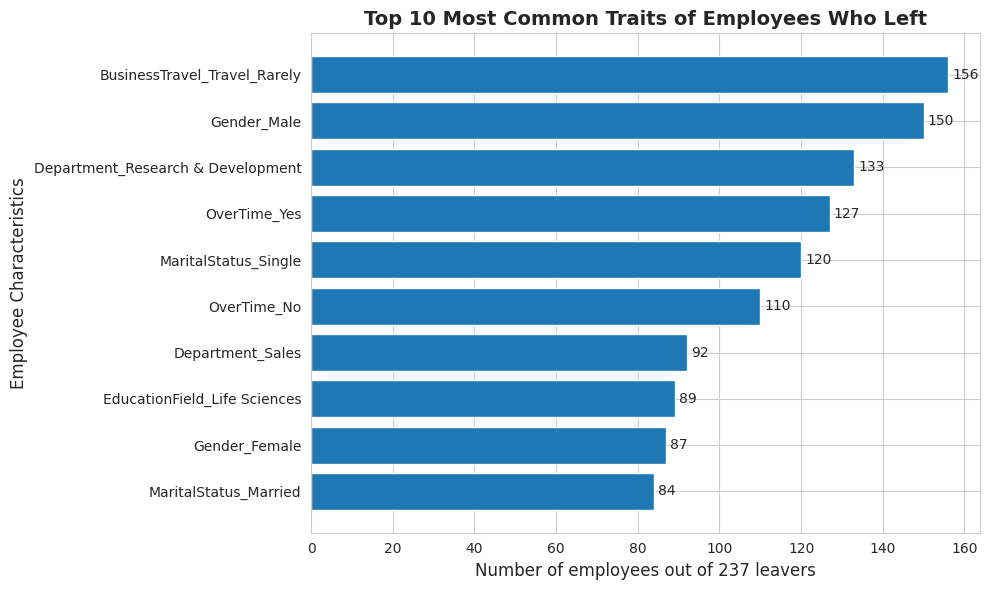

In [11]:
plt.figure(figsize=(10, 6))
top_10 = distribution.head(10)
x = top_10.values
y = top_10.index
plt.barh(y, x)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Common Traits of Employees Who Left', fontsize=14, fontweight='bold')
plt.xlabel('Number of employees out of 237 leavers', fontsize=12)
plt.ylabel('Employee Characteristics', fontsize=12)

for i, value in enumerate(top_10.values):
    plt.text(value + 1, i, str(value), va='center')

plt.tight_layout()
plt.show()

**Takeaway:** These are raw counts, not rates — they naturally favor whichever groups are largest in the company overall, so this is a first hint of where to look, not proof of what matters. Section 4 (Correlation Analysis) confirms which of these traits actually move the needle statistically.

### 3.3 Does Pay Influence Attrition?

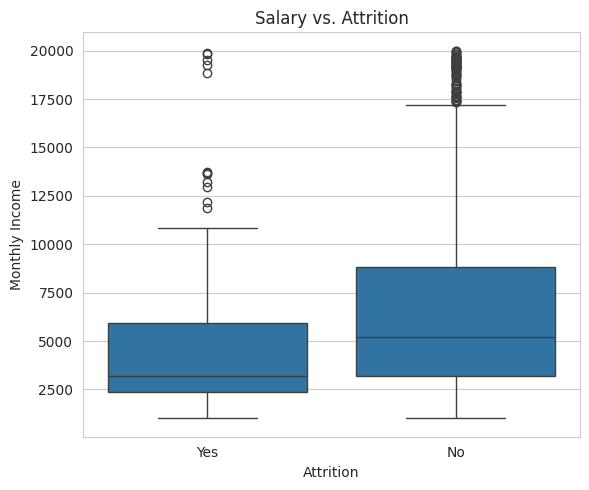

In [12]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=ibm_data)
plt.title('Salary vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

**Takeaway:** Employees who left earned visibly less than those who stayed, both in median income and the overall spread — a real pay gap between leavers and stayers, not just a couple of outliers.

### 3.4 Does Age or Experience Play a Role?

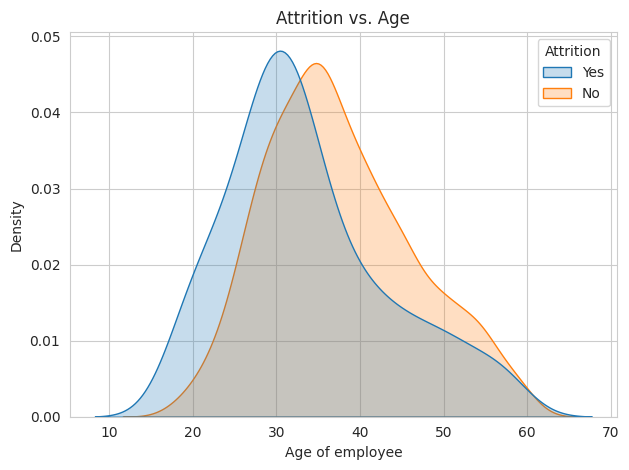

In [13]:
sns.kdeplot(data=ibm_data, x='Age', hue='Attrition', fill=True, common_norm=False)
plt.title('Attrition vs. Age')
plt.xlabel('Age of employee')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

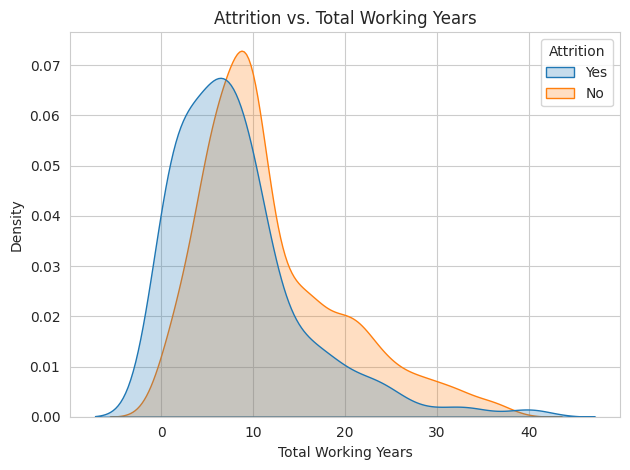

In [14]:
sns.kdeplot(data=ibm_data, x='TotalWorkingYears', hue='Attrition', fill=True, common_norm=False)
plt.title('Attrition vs. Total Working Years')
plt.xlabel('Total Working Years')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [15]:
age_by_attrition = ibm_data.groupby('Attrition')['Age'].mean()
tenure_by_attrition = ibm_data.groupby('Attrition')['TotalWorkingYears'].mean()

print("Average age by attrition status:")
print(age_by_attrition.round(1))
print("\nAverage total working years by attrition status:")
print(tenure_by_attrition.round(1))

Average age by attrition status:
Attrition
No     37.6
Yes    33.6
Name: Age, dtype: float64

Average total working years by attrition status:
Attrition
No     11.9
Yes     8.2
Name: TotalWorkingYears, dtype: float64


**Takeaway:** Both distributions skew the same way — employees who leave are, on average, younger and less experienced than those who stay. Early-career staff appear to be the higher flight-risk group.

### 3.5 Does Commute Distance Matter?

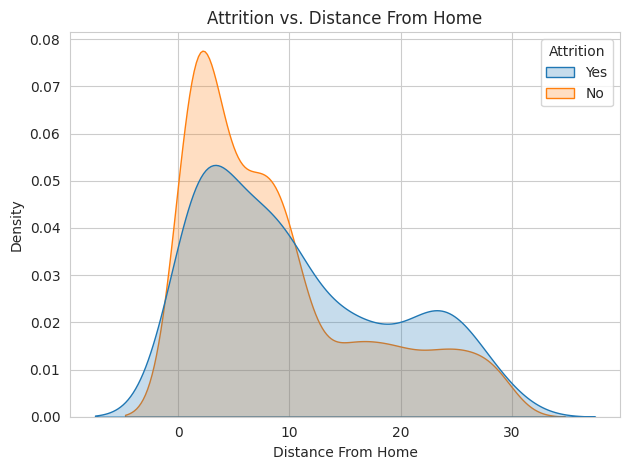

In [16]:
sns.kdeplot(data=ibm_data, x='DistanceFromHome', hue='Attrition', fill=True, common_norm=False)
plt.title('Attrition vs. Distance From Home')
plt.xlabel('Distance From Home')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

**Takeaway:** Employees who live closer to the office are more likely to stay; the density of leavers shifts noticeably toward longer commutes.

### 3.6 Which Departments Are Hit Hardest?

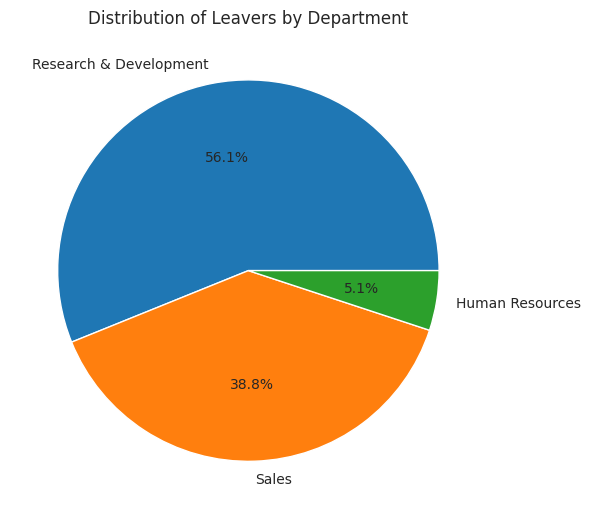

In [17]:
leavers_per_dept = ibm_data[ibm_data['Attrition'] == 'Yes']['Department'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(leavers_per_dept, labels=leavers_per_dept.index, autopct='%1.1f%%')
plt.title('Distribution of Leavers by Department')
plt.tight_layout()
plt.show()

In [18]:
# Share of leavers (above) can be misleading if departments differ in size.
# The attrition RATE within each department is the fairer comparison:
dept_attrition_rate = (ibm_data.groupby('Department')['Attrition_num'].mean() * 100).sort_values(ascending=False)
dept_attrition_rate.round(1)

Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition_num, dtype: float64

**Takeaway:** Sales accounts for the largest *share* of leavers, but that partly reflects department size. Looking at the attrition *rate* within each department gives the fairer picture of which team is proportionally losing the most people.

### 3.7 Does Overtime Drive Attrition?

In [19]:
overtime_rates = ibm_data.groupby('OverTime')['Attrition_num'].mean() * 100
rate_yes = overtime_rates['Yes']
rate_no = overtime_rates['No']
difference = rate_yes - rate_no
multiplier = rate_yes / rate_no

print(f"Attrition rate for No overtime: {rate_no:.2f}%")
print(f"Attrition rate for Yes overtime: {rate_yes:.2f}%")
print(f"Working overtime increases the attrition rate by: {difference:.2f} percentage points")
print(f"Employees who work overtime are {multiplier:.1f}x more likely to quit")

Attrition rate for No overtime: 10.44%
Attrition rate for Yes overtime: 30.53%
Working overtime increases the attrition rate by: 20.09 percentage points
Employees who work overtime are 2.9x more likely to quit


**Takeaway:** This is the single clearest split in the whole dataset — overtime employees leave at nearly three times the rate of everyone else.

## 4. Correlation Analysis

The patterns above are suggestive but not yet statistically ranked. To find out which factors actually correlate most strongly with attrition — and to avoid over-weighting whatever looked visually striking — I calculate Pearson correlation coefficients against `Attrition_num`: first for numeric fields, then for one-hot-encoded categorical fields.

### 4.1 Numeric Correlations

In [20]:
ibm_numeric = ibm_data.select_dtypes(include='number')
ibm_numeric = ibm_numeric.drop(columns=['EmployeeCount', 'StandardHours'])
correlation = ibm_numeric.corr()['Attrition_num'].sort_values(ascending=False)
correlation

Attrition_num               1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition_num, dtype: float64

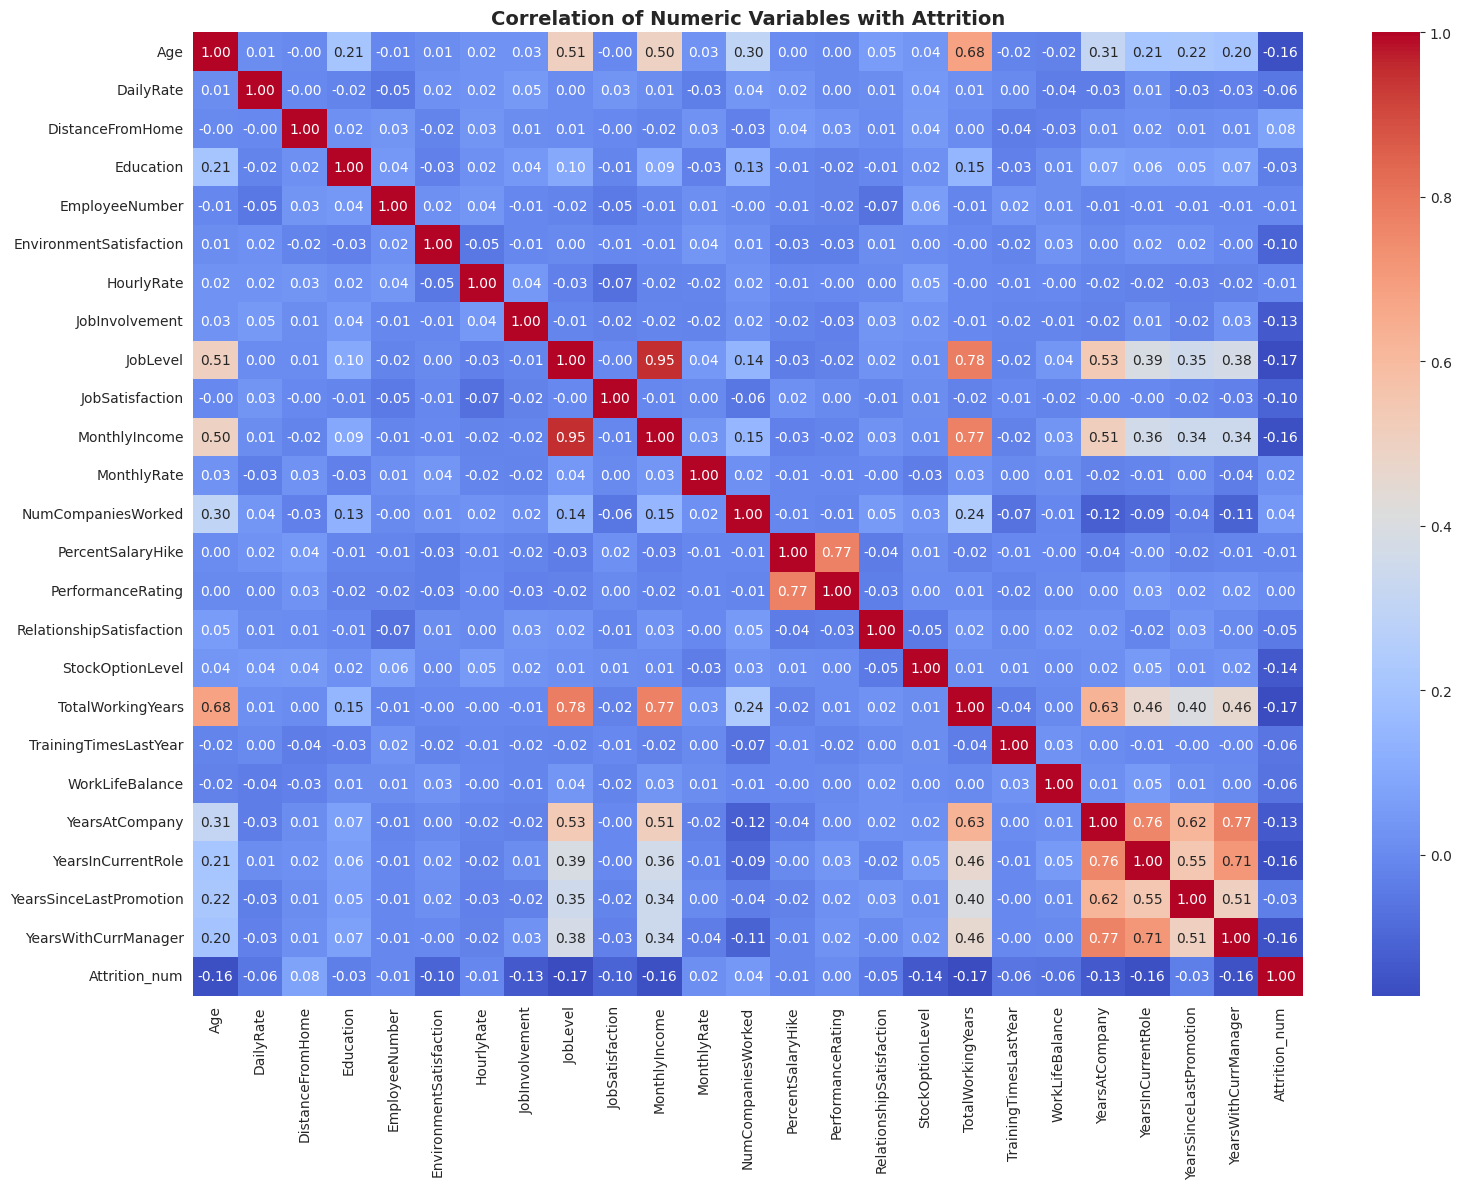

In [21]:
plt.figure(figsize=(16, 12))
sns.heatmap(ibm_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of Numeric Variables with Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Takeaway:** `DistanceFromHome` has the highest positive correlation with attrition of any numeric field, while `TotalWorkingYears`, `JobLevel`, `YearsInCurrentRole`, `MonthlyIncome`, and `Age` are the strongest *negative* correlates — all pointing the same way as the EDA above.

Worth flagging honestly: every one of these coefficients is fairly weak in absolute terms (the strongest is around ±0.17). No single numeric variable drives attrition on its own — it's a combination of factors, which is exactly why the categorical correlations and the overtime effect matter just as much as these numbers.

### 4.2 Categorical Correlations

In [22]:
cat_corr = ibm_cat_data.corr()['Attrition_num'].sort_values(ascending=False)
cat_corr

Attrition_num                        1.000000
OverTime_Yes                         0.246118
MaritalStatus_Single                 0.175419
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
EducationField_Human Resources       0.036466
JobRole_Human Resources              0.036215
Gender_Male                          0.029453
JobRole_Sales Executive              0.019774
Department_Human Resources           0.016832
JobRole_Research Scientist          -0.000360
EducationField_Other                -0.017898
Gender_Female                       -0.029453
EducationField_Life Sciences        -0.032703
EducationField_Medical              -0.046999
BusinessTravel_Travel_Rarely        -0.049538
BusinessTravel_Non-Travel           -0.074457
JobRole_Healthcare Representative 

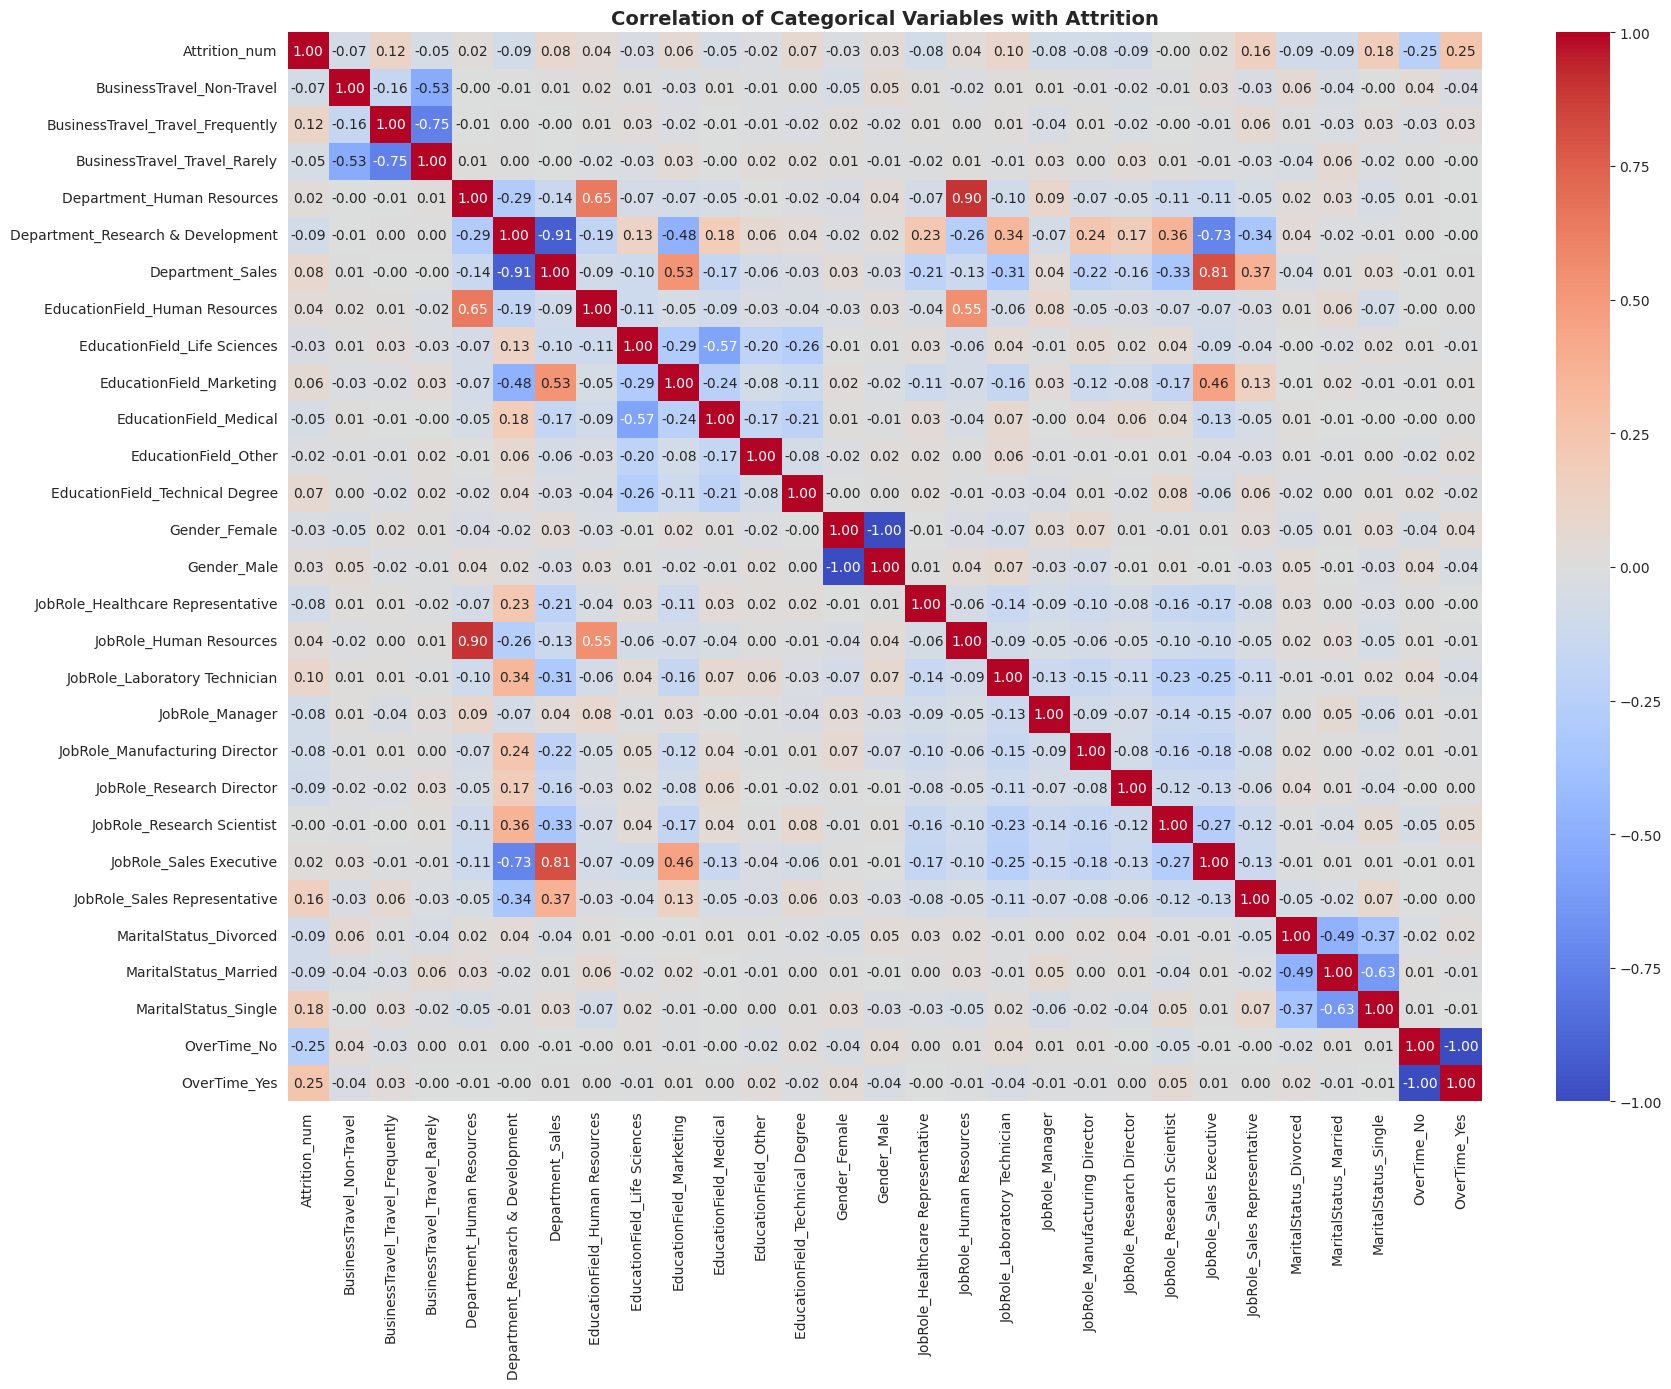

In [23]:
plt.figure(figsize=(18, 14))
sns.heatmap(ibm_cat_data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation of Categorical Variables with Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Takeaway:** `OverTime_Yes` (r ≈ 0.25) is the strongest correlate in the *entire* dataset — numeric or categorical — which lines up exactly with the 2.9x gap found in Section 3.7. Being single, traveling frequently, and working as a Sales Representative also show meaningfully elevated attrition.

## 5. Key Findings

Bringing the EDA and correlation results together:

1. **Overtime is the dominant factor, by a wide margin.** 30.5% attrition among overtime workers vs. 10.4% among everyone else, and the strongest correlation (r ≈ 0.25) of any variable in the dataset.
2. **Compensation is a secondary but real driver.** Leavers earned visibly less than stayers, and `MonthlyIncome` is among the top negative numeric correlates.
3. **Commute distance is the leading numeric factor**, though its effect size is modest on its own — it compounds with the other drivers rather than acting alone.
4. **Junior, early-career employees are the highest-risk group.** Lower age, fewer total working years, and lower job level all correlate with leaving; tenure and seniority are protective.
5. **Risk concentrates in specific segments** — single employees, frequent travelers, and Sales Representatives — rather than being evenly spread across the company.

## 6. Recommendations

1. **Rein in overtime reliance.** This is the single strongest lever available — rebalancing workloads or hiring to reduce mandatory overtime should be the first place HR intervenes.
2. **Close the pay gap**, prioritizing junior and lower-tenure employees, where both the income gap and the attrition risk are highest.
3. **Offer hybrid work or flexible start times** for employees with long commutes, since distance is the leading numeric risk factor.
4. **Target retention efforts** at early-tenure, single employees and the Sales department specifically, rather than applying a uniform company-wide policy.

## 7. Limitations & Future Work

- **Correlation isn't causation.** These results show which factors move together with attrition, not that any one of them directly *causes* someone to leave. Confirming causal drivers would need controlled comparisons or a designed intervention (e.g., piloting reduced overtime in one team and measuring the change).
- **Single, static snapshot.** The dataset captures one point in time. A longitudinal view — tracking the same employees over multiple years — would show whether these risk factors predict *when* someone leaves, not just *whether* they do.
- **No cost data.** The analysis identifies drivers of attrition but not the dollar cost of each departure, which HR would need to prioritize interventions by ROI.
- **Next step:** the individual correlations above are weak on their own, which suggests attrition is genuinely multi-factor. A predictive model (e.g., logistic regression) that combines all variables at once — rather than examining them one at a time — would likely explain more of the variation and could flag specific at-risk employees before they leave.